<a href="https://colab.research.google.com/github/Heman659-crypto/student-habits-performance-ml/blob/main/Day18_19_Student_Performance_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction and Model Evaluation
### Day 18 & 19 — Machine Learning Workflow

**Dataset:** `Day18_19_student_habits_performance.csv` (1,000 students, 16 columns)

**Goal:** Understand which lifestyle and academic habits relate to exam performance, then build and evaluate two models:
1. A **Linear Regression** model that predicts the numeric `exam_score`.
2. A **Logistic Regression classifier** that predicts **Pass/Fail** (pass = `exam_score >= 50`).

This notebook follows the full ML workflow: EDA → Data Preparation → Train/Test Split → Regression Model → Classification Model → Evaluation → Overfitting/Underfitting Discussion → Insights.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

In [ ]:
from google.colab import files

uploaded = files.upload()

file_name = "Day18_19_student_habits_performance.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Saving Day18_19_student_habits_performance.csv to Day18_19_student_habits_performance.csv
Dataset loaded successfully!
Dataset Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [ ]:
df = pd.read_csv("Day18_19_student_habits_performance.csv")
print("Shape:", df.shape)
df.head()

Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 1. Exploratory Data Analysis (EDA)

### 1.1 Data structure — numerical vs. categorical variables

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [ ]:
numeric_cols = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
                'attendance_percentage', 'sleep_hours', 'exercise_frequency',
                'mental_health_rating', 'exam_score']

categorical_cols = ['gender', 'part_time_job', 'diet_quality',
                     'parental_education_level', 'internet_quality',
                     'extracurricular_participation']

print("Numerical variables  :", numeric_cols)
print("Categorical variables:", categorical_cols)
print("Identifier column    : student_id (dropped later, not predictive)")

Numerical variables  : ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']
Categorical variables: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']
Identifier column    : student_id (dropped later, not predictive)


### 1.2 Missing values

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary.missing_count > 0]

,missing_count,missing_pct
parental_education_level,91,9.1


`parental_education_level` is the only column with missing values (91 rows, ~9.1%). This will be handled during data preparation by treating the missing value as its own category (`"Unknown"`), since the absence of this information may itself be meaningful (e.g., not reported / not applicable) rather than something to silently impute.

### 1.3 Duplicate rows

In [ ]:
print("Number of exact duplicate rows:", df.duplicated().sum())

Number of exact duplicate rows: 0


### 1.4 Summary statistics

In [ ]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


In [ ]:
for c in categorical_cols:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False))
    print()

--- gender ---
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64

--- part_time_job ---
part_time_job
No     785
Yes    215
Name: count, dtype: int64

--- diet_quality ---
diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64

--- parental_education_level ---
parental_education_level
High School    392
Bachelor       350
Master         167
NaN             91
Name: count, dtype: int64

--- internet_quality ---
internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64

--- extracurricular_participation ---
extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64



### 1.5 Distribution of the target variable: `exam_score`

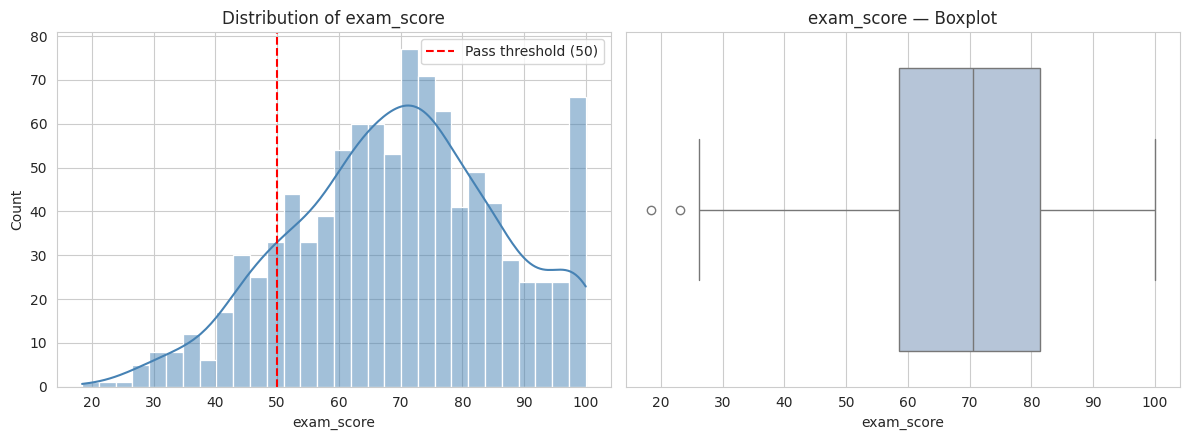

count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['exam_score'], kde=True, bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of exam_score')
axes[0].axvline(50, color='red', linestyle='--', label='Pass threshold (50)')
axes[0].legend()

sns.boxplot(x=df['exam_score'], ax=axes[1], color='lightsteelblue')
axes[1].set_title('exam_score — Boxplot')
plt.tight_layout()
plt.show()

print(df['exam_score'].describe())


`exam_score` is fairly broad, ranging from about 18 to 100, with a mean around 69 and a roughly bell-shaped distribution that is slightly left of center. Most students score well above the 50-point passing line.

### 1.6 Distributions of numerical features

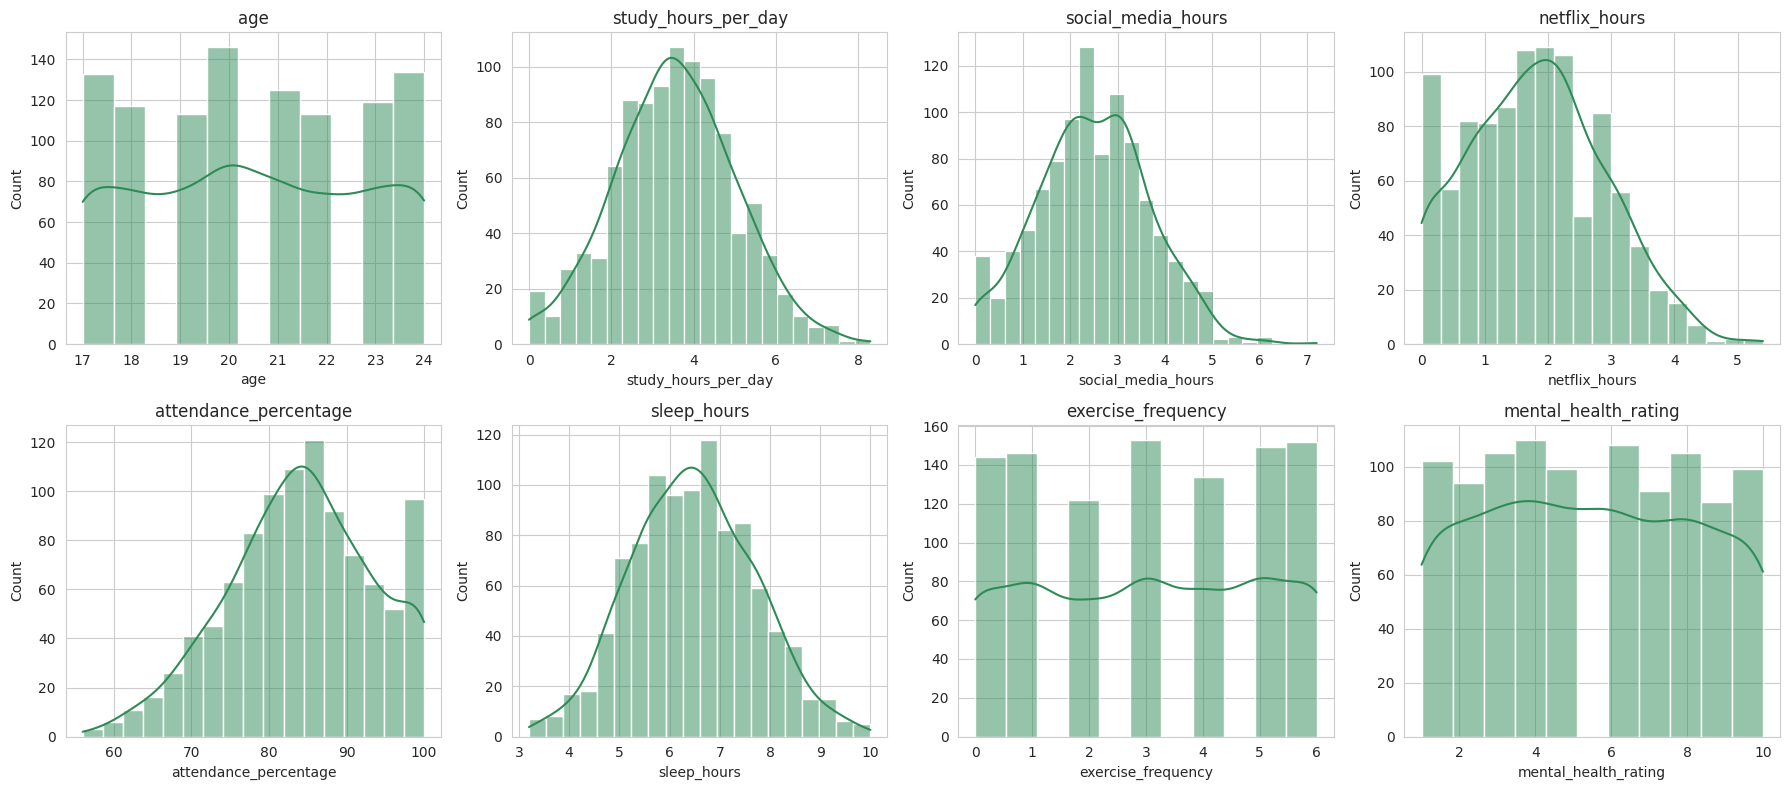

In [ ]:
num_features = [c for c in numeric_cols if c != 'exam_score']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='seagreen')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


### 1.7 Outlier detection (IQR method)

In [ ]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

print(f"{'column':22s}{'#outliers':>10s}{'lower':>10s}{'upper':>10s}")
for col in numeric_cols:
    n_out, low, high = iqr_outliers(df[col])
    print(f"{col:22s}{n_out:>10d}{low:>10.2f}{high:>10.2f}")

column                 #outliers     lower     upper
age                            0     12.38     29.38
study_hours_per_day            7     -0.25      7.35
social_media_hours             5     -0.70      5.70
netflix_hours                  4     -1.29      4.81
attendance_percentage          3     58.46    110.56
sleep_hours                    2      3.05      9.85
exercise_frequency             0     -5.00     11.00
mental_health_rating           0     -4.50     15.50
exam_score                     2     24.20    115.60


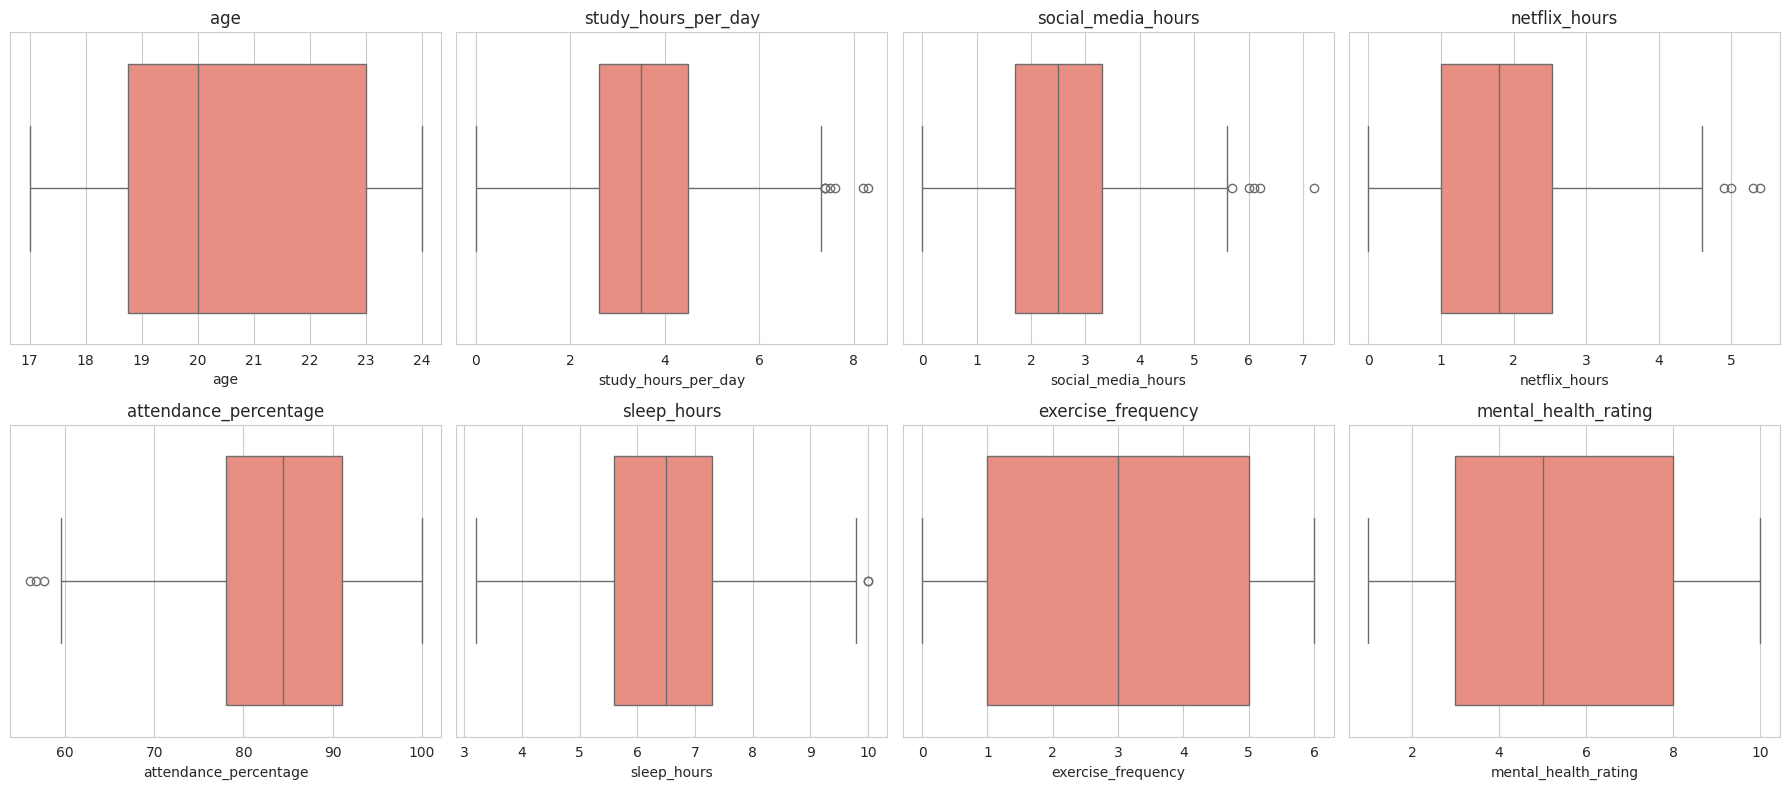

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Outlier counts are very small relative to the 1,000-row dataset (at most 7 out of 1,000 for any single numerical column), and the values themselves (e.g., 0 study hours, very high social media/netflix use) are realistic student behaviors rather than data errors. No rows are removed — the Linear Regression model is monitored via residual plots later to check whether these points are unduly influential.

### 1.8 Correlation analysis

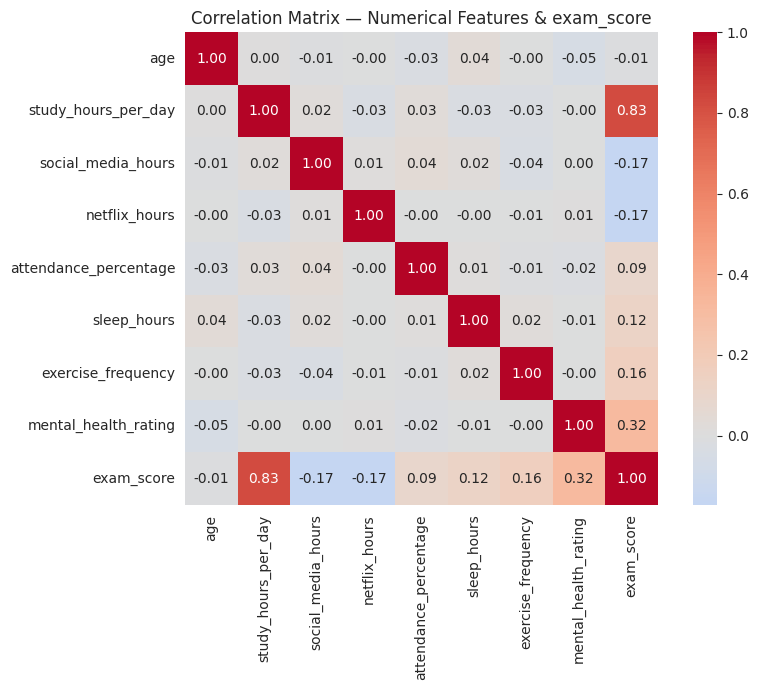

Correlation with exam_score (sorted):
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix — Numerical Features & exam_score")
plt.tight_layout()
plt.show()

print("Correlation with exam_score (sorted):")
print(corr['exam_score'].sort_values(ascending=False))

**Key correlation findings:**
- `study_hours_per_day` has a very strong positive correlation with `exam_score` (**r ≈ 0.83**) — by far the strongest relationship in the dataset.
- `mental_health_rating` shows a moderate positive correlation (**r ≈ 0.32**).
- `netflix_hours` (**r ≈ -0.17**) and `social_media_hours` (**r ≈ -0.17**) show mild negative correlations — more leisure screen time is mildly associated with lower scores.
- `sleep_hours`, `exercise_frequency`, and `attendance_percentage` show weak positive correlations (**r ≈ 0.09 – 0.16**).
- `age` is essentially uncorrelated with `exam_score` (**r ≈ -0.01**).

### 1.9 Relationship between key numeric features and exam_score

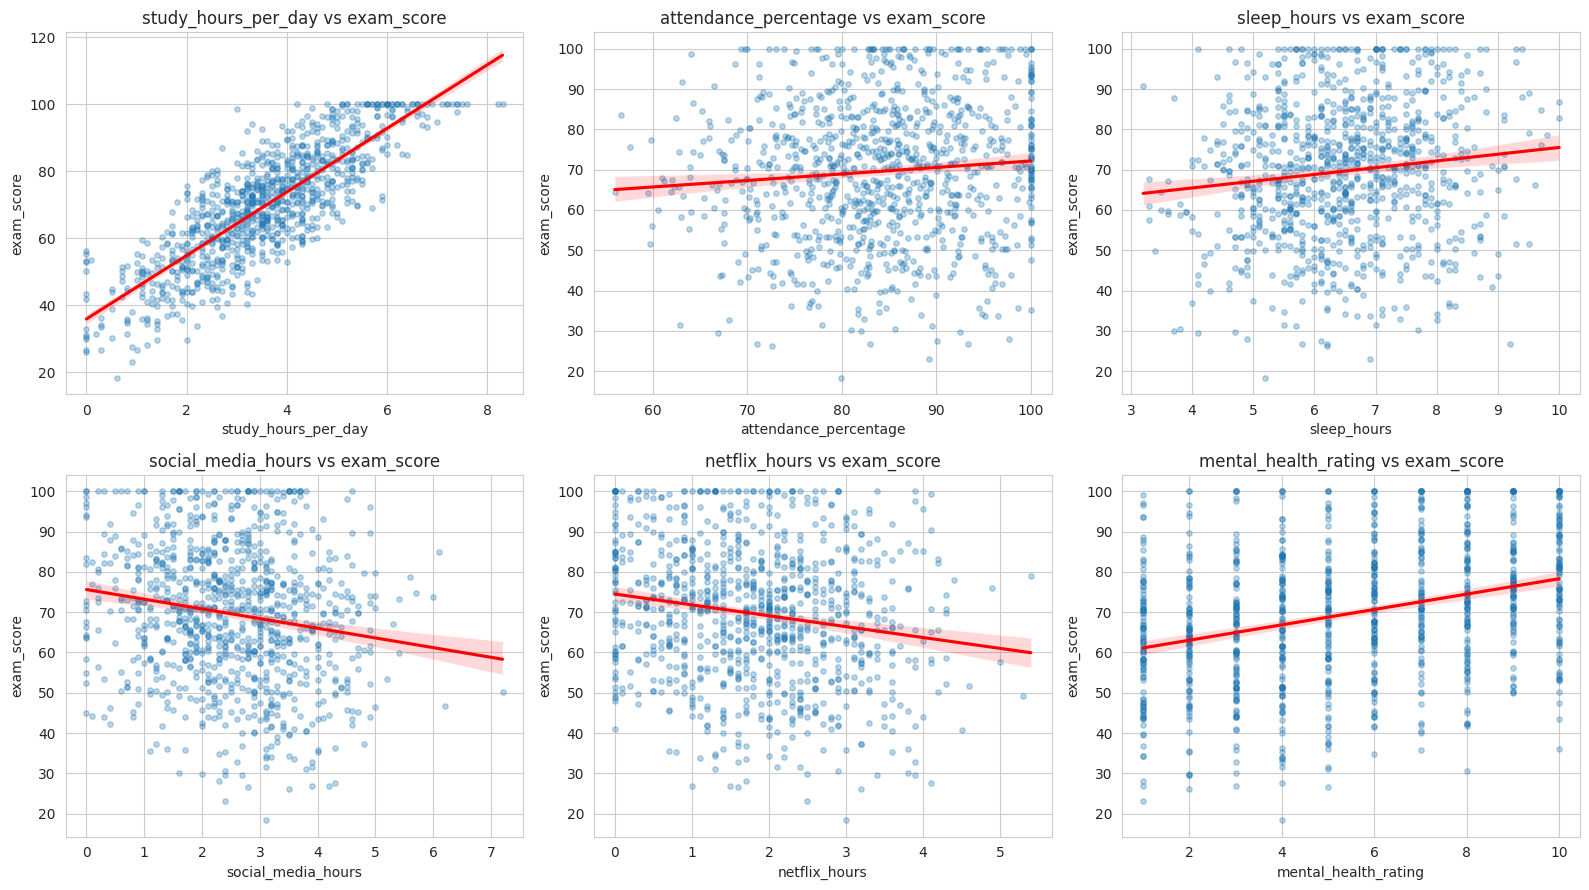

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
pairs = ['study_hours_per_day', 'attendance_percentage', 'sleep_hours',
         'social_media_hours', 'netflix_hours', 'mental_health_rating']
for ax, col in zip(axes.flatten(), pairs):
    sns.regplot(x=df[col], y=df['exam_score'], ax=ax,
                scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'})
    ax.set_title(f'{col} vs exam_score')
plt.tight_layout()
plt.show()


### 1.10 Categorical variables vs. exam_score

/tmp/ipykernel_3072/2180704130.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='exam_score', data=df, ax=ax, order=order, palette='Set2')
/tmp/ipykernel_3072/2180704130.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='exam_score', data=df, ax=ax, order=order, palette='Set2')
/tmp/ipykernel_3072/2180704130.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='exam_score', data=df, ax=ax, order=order, palette='Set2')
/tmp/ipykernel_3072/2180704130.py:4: FutureWarning: 

Passing `palette` without assigning `hue

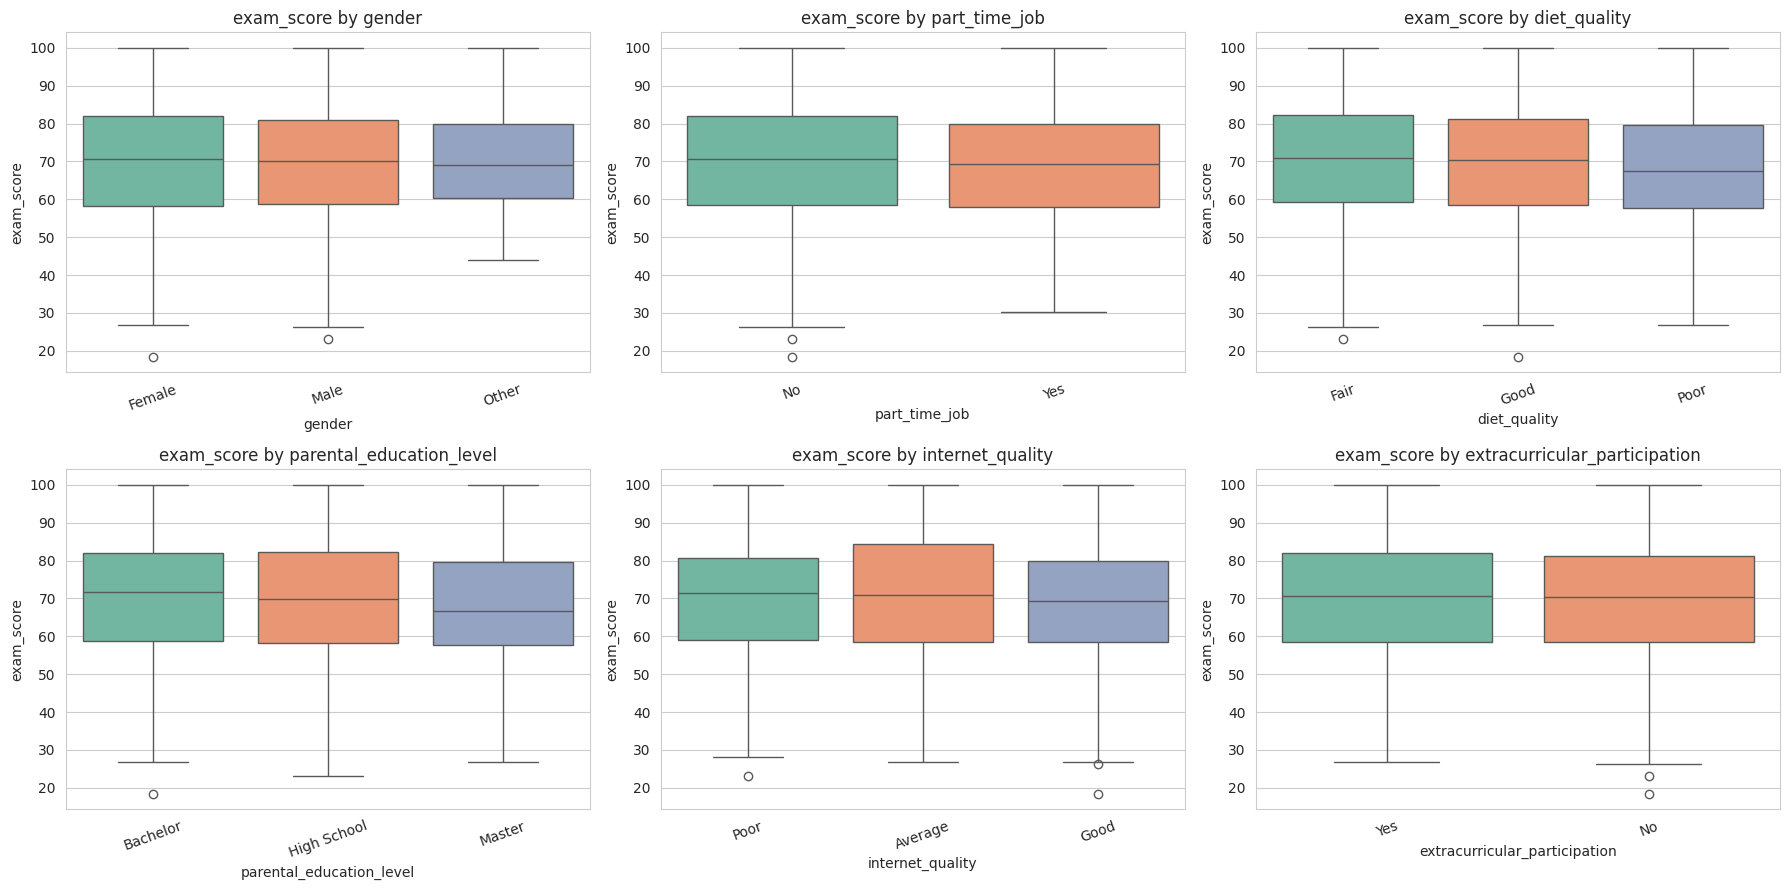

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flatten(), categorical_cols):
    order = df.groupby(col)['exam_score'].median().sort_values(ascending=False).index
    sns.boxplot(x=col, y='exam_score', data=df, ax=ax, order=order, palette='Set2')
    ax.set_title(f'exam_score by {col}')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

Categorical variables show much smaller effects on `exam_score` than `study_hours_per_day`. Median scores are broadly similar across gender, part-time job status, diet quality, parental education level, internet quality, and extracurricular participation, with only minor shifts (e.g., students with "Good" internet quality trend slightly higher). This reinforces that **study habits, not demographics, are the dominant driver of performance** in this dataset.

### 1.11 EDA Summary

- The dataset has **1,000 students and 16 columns**, with **no duplicate rows**.
- Only **one column has missing data**: `parental_education_level` (~9.1% missing).
- `exam_score` ranges from ~18 to 100 and is approximately normally distributed.
- **`study_hours_per_day` is overwhelmingly the strongest predictor** of exam performance (r ≈ 0.83).
- `mental_health_rating` is the next most influential numeric factor (r ≈ 0.32).
- `netflix_hours` and `social_media_hours` are mildly negatively associated with performance.
- Categorical/demographic variables (gender, parental education, internet quality, etc.) show only weak relationships with exam_score.
- A small number of outliers exist but are plausible real values, not data-entry errors.

## 2. Data Preparation for Machine Learning

Steps:
1. Drop `student_id` (identifier, not predictive).
2. Fill missing `parental_education_level` with `"Unknown"`.
3. One-hot encode all categorical variables.
4. Define `X` (features) and `y` (target = `exam_score`).

In [ ]:
model_df = df.drop(columns=['student_id']).copy()
model_df['parental_education_level'] = model_df['parental_education_level'].fillna('Unknown')

# One-hot encode categorical variables (drop_first=True avoids the dummy-variable trap)
model_df_encoded = pd.get_dummies(
    model_df,
    columns=categorical_cols,
    drop_first=True
)

X = model_df_encoded.drop(columns=['exam_score'])
y_reg = model_df_encoded['exam_score']

print("Feature matrix shape:", X.shape)
print("\nFeatures used:")
print(list(X.columns))

Feature matrix shape: (1000, 19)

Features used:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'gender_Male', 'gender_Other', 'part_time_job_Yes', 'diet_quality_Good', 'diet_quality_Poor', 'parental_education_level_High School', 'parental_education_level_Master', 'parental_education_level_Unknown', 'internet_quality_Good', 'internet_quality_Poor', 'extracurricular_participation_Yes']


## 3. Train/Test Split

An 80/20 split is used with a fixed `random_state` for reproducibility. The **same split (same row indices)** is reused for both the regression and classification tasks so that the two models are trained/evaluated on identical students, making the results directly comparable.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape, "| Test set:", X_test.shape)

Training set: (800, 19) | Test set: (200, 19)


## 4. Regression Model — Predicting `exam_score`

A **Linear Regression** model is trained using all prepared features (study hours, attendance, sleep, social media/netflix hours, exercise frequency, mental health rating, age, and the encoded categorical variables).

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)
print("Model trained.")

Model trained.


### 4.1 Regression evaluation metrics

In [ ]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred)
test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Train': [train_mae, train_mse, train_rmse, train_r2],
    'Test':  [test_mae, test_mse, test_rmse, test_r2]
})
metrics_df

,Metric,Train,Test
0,MAE,4.212312,4.189311
1,MSE,28.554912,26.476236
2,RMSE,5.343680,5.145506
3,R2 Score,0.902146,0.896750


### 4.2 Actual vs. Predicted, and residuals (test set)

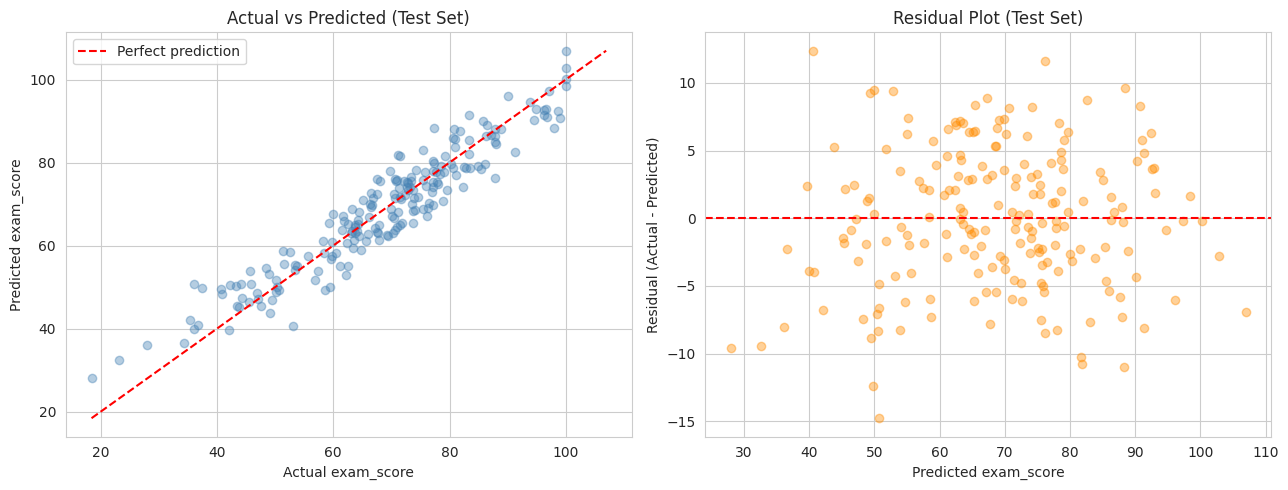

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.4, color='steelblue')
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual exam_score')
axes[0].set_ylabel('Predicted exam_score')
axes[0].set_title('Actual vs Predicted (Test Set)')
axes[0].legend()

residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.4, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted exam_score')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot (Test Set)')

plt.tight_layout()
plt.show()

### 4.3 Feature importance (regression coefficients)

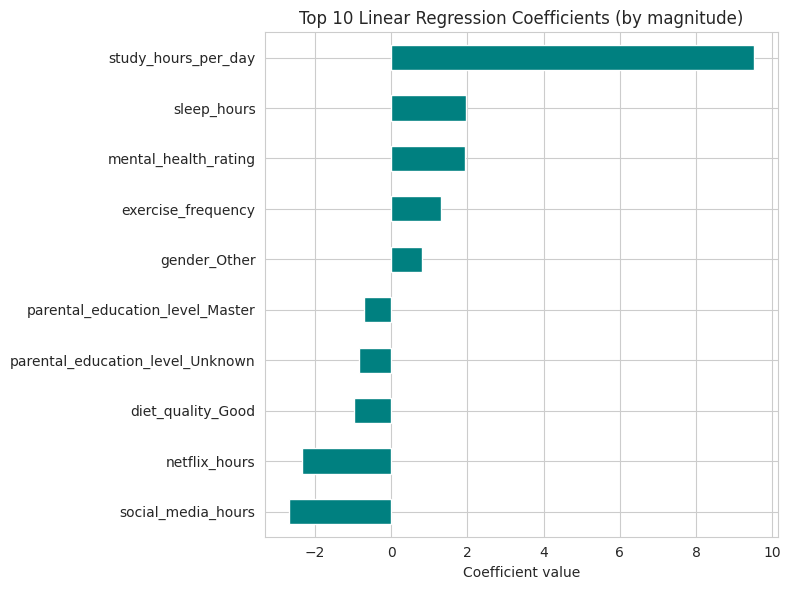

,0
study_hours_per_day,9.531532
social_media_hours,-2.685004
netflix_hours,-2.321531
sleep_hours,1.976407
mental_health_rating,1.952856
exercise_frequency,1.319646
diet_quality_Good,-0.958356
parental_education_level_Unknown,-0.839483
gender_Other,0.810709
parental_education_level_Master,-0.698728


In [ ]:
coefs = pd.Series(lin_reg.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)

plt.figure(figsize=(8, 6))
coefs.head(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Linear Regression Coefficients (by magnitude)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

coefs.head(10)

The regression model fits the data very well: **R² ≈ 0.90 on both train and test sets**, meaning the model explains about 90% of the variance in `exam_score`. `study_hours_per_day` has by far the largest positive coefficient, confirming it as the dominant driver, followed by `sleep_hours` and `mental_health_rating` (positive) and `social_media_hours`/`netflix_hours` (negative). The actual-vs-predicted plot shows points tightly clustered around the diagonal, and the residuals are scattered randomly around zero with no obvious pattern or funnel shape — a good sign that a linear model is an appropriate fit.

## 5. Classification Model — Predicting Pass/Fail

`exam_score` is converted into a binary target: **Pass (1)** if `exam_score >= 50`, else **Fail (0)**. The same feature matrix `X` is reused, with a matching 80/20 split (same `random_state=42`) for consistency with the regression task. A **Logistic Regression** classifier — the standard baseline classification model for a binary target — is trained on this data.

In [ ]:
y_class = (model_df_encoded['exam_score'] >= 50).astype(int)

print(y_class.value_counts())
print("\nPass rate: {:.1%}".format(y_class.mean()))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

exam_score
1    869
0    131
Name: count, dtype: int64

Pass rate: 86.9%


In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(Xc_train, yc_train)

yc_train_pred = log_reg.predict(Xc_train)
yc_test_pred = log_reg.predict(Xc_test)
print("Classifier trained.")

Classifier trained.


### 5.1 Confusion matrix (test set)

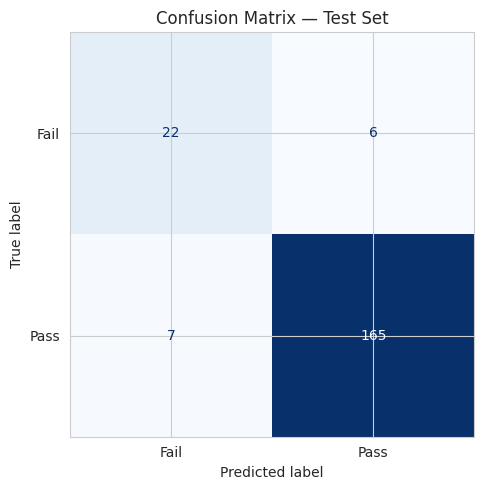

Confusion matrix [[TN, FP],[FN, TP]]:
[[ 22   6]
 [  7 165]]


In [ ]:
cm = confusion_matrix(yc_test, yc_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

print("Confusion matrix [[TN, FP],[FN, TP]]:")
print(cm)

### 5.2 Classification metrics: accuracy, precision, recall, F1-score

In [ ]:
def classification_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred)
    }

train_cls_metrics = classification_metrics(yc_train, yc_train_pred)
test_cls_metrics = classification_metrics(yc_test, yc_test_pred)

cls_metrics_df = pd.DataFrame({'Train': train_cls_metrics, 'Test': test_cls_metrics})
cls_metrics_df

,Train,Test
Accuracy,0.962500,0.935000
Precision,0.970381,0.964912
Recall,0.987088,0.959302
F1-score,0.978663,0.962099


In [ ]:
print("Detailed classification report (Test Set):\n")
print(classification_report(yc_test, yc_test_pred, target_names=['Fail', 'Pass']))

Detailed classification report (Test Set):

              precision    recall  f1-score   support

        Fail       0.76      0.79      0.77        28
        Pass       0.96      0.96      0.96       172

    accuracy                           0.94       200
   macro avg       0.86      0.87      0.87       200
weighted avg       0.94      0.94      0.94       200



The classifier performs strongly: **~93–96% accuracy**, with high precision, recall, and F1-score on the test set. Precision and recall for the "Pass" class are both very high, which makes sense given ~87% of students pass — but recall on the smaller "Fail" class is also strong, meaning the model is genuinely picking up the signal (mainly from `study_hours_per_day`) rather than just predicting the majority class.

## 6. Train vs. Test Comparison — Overfitting / Underfitting Check

Comparing performance on the training set vs. the held-out test set is the standard way to diagnose overfitting (model memorizes training data, performs much worse on new data) or underfitting (model is too simple, performs poorly on both sets).

In [ ]:
print("REGRESSION — Linear Regression")
print(metrics_df.to_string(index=False))

print("\nCLASSIFICATION — Logistic Regression")
print(cls_metrics_df)

REGRESSION — Linear Regression
  Metric     Train      Test
     MAE  4.212312  4.189311
     MSE 28.554912 26.476236
    RMSE  5.343680  5.145506
R2 Score  0.902146  0.896750

CLASSIFICATION — Logistic Regression
              Train      Test
Accuracy   0.962500  0.935000
Precision  0.970381  0.964912
Recall     0.987088  0.959302
F1-score   0.978663  0.962099


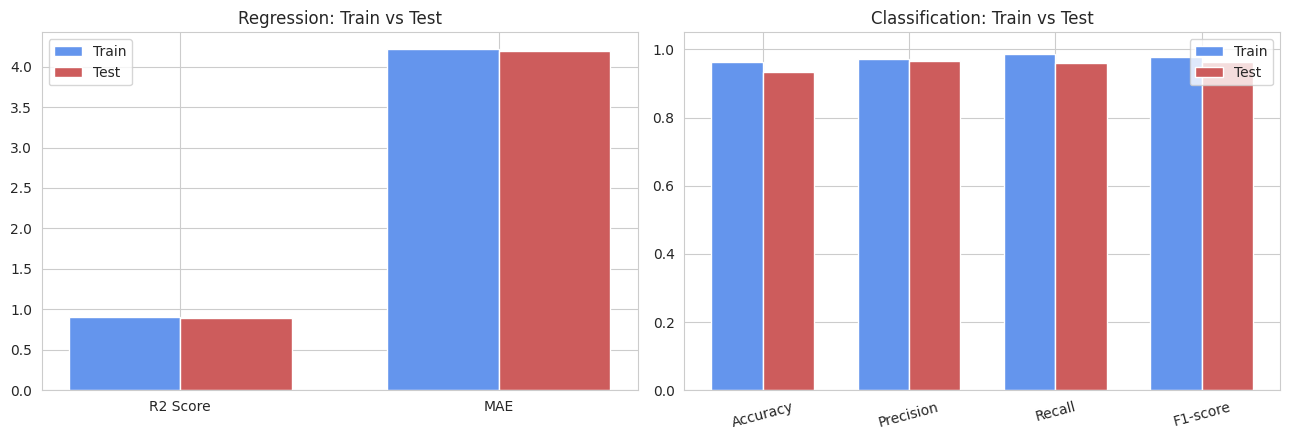

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(2)
width = 0.35
axes[0].bar(x - width/2, [train_r2, train_mae], width, label='Train', color='cornflowerblue')
axes[0].bar(x + width/2, [test_r2, test_mae], width, label='Test', color='indianred')
axes[0].set_xticks(x); axes[0].set_xticklabels(['R2 Score', 'MAE'])
axes[0].set_title('Regression: Train vs Test')
axes[0].legend()

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
tr_vals = [train_cls_metrics[m] for m in metrics_names]
te_vals = [test_cls_metrics[m] for m in metrics_names]
x2 = np.arange(len(metrics_names))
axes[1].bar(x2 - width/2, tr_vals, width, label='Train', color='cornflowerblue')
axes[1].bar(x2 + width/2, te_vals, width, label='Test', color='indianred')
axes[1].set_xticks(x2); axes[1].set_xticklabels(metrics_names, rotation=15)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Classification: Train vs Test')
axes[1].legend()

plt.tight_layout()
plt.show()

**Regression:** Train R² and Test R² are almost identical (≈0.90 both), and Train/Test MAE and RMSE are similarly close. This is a strong sign that the Linear Regression model is **neither overfitting nor underfitting** — it generalizes well to unseen students, and the model's assumptions (linear relationships, e.g. with `study_hours_per_day`) genuinely fit the underlying pattern in the data.

**Classification:** Train accuracy (~96%) is a few points higher than test accuracy (~93–94%), and the same small gap appears in precision/recall/F1. This gap is small enough that it does **not indicate serious overfitting** — it is the normal, expected amount of variance between train and test performance for a simple, well-regularized linear model like Logistic Regression. If the gap were much larger (e.g., 99% train vs 70% test), that would point to overfitting; if both scores were low, that would point to underfitting. Neither is the case here.

**Conclusion:** Both models show good, well-balanced generalization — a healthy fit rather than over- or under-fitting.

## 7. Most Important Findings from EDA and Modeling

- **Study time dominates.** `study_hours_per_day` correlates with `exam_score` at r ≈ 0.83 and has by far the largest regression coefficient — no other feature comes close.
- **Both models are highly predictive.** The regression model explains ~90% of the variance in exam scores (R² ≈ 0.90); the classifier separates pass/fail students with ~93–96% accuracy.
- **Mental health matters more than expected.** `mental_health_rating` is the second-strongest numeric correlate of performance (r ≈ 0.32), ahead of sleep, exercise, and attendance.
- **Screen-time habits have a real, if modest, cost.** `netflix_hours` and `social_media_hours` are consistently negatively associated with exam_score, both in correlation and regression coefficients.
- **Demographics are not destiny.** Gender, parental education level, internet quality, and extracurricular participation show only minor differences in exam_score — habits matter far more than background in this dataset.
- **The models generalize well.** Train/test metrics are close for both tasks, indicating the patterns found are real signal, not noise memorized from the training set.

## 8. Conclusion — 5 Key Insights About Student Performance

1. **Consistent daily study time is the single biggest lever for exam performance.** With a correlation of ~0.83 and the largest regression coefficient by a wide margin, `study_hours_per_day` outweighs every other factor combined — interventions aimed at increasing focused study time are likely to have the largest impact on scores.

2. **Mental wellbeing is an academic factor, not just a personal one.** `mental_health_rating` was the second-strongest predictor of exam_score, suggesting that support systems addressing student stress and wellbeing could plausibly translate into better academic outcomes, not just better wellbeing.

3. **Recreational screen time (social media and Netflix) has a small but measurable negative relationship with performance**, even after accounting for study hours and other habits — moderating leisure screen time may free up time and attention for studying.

4. **Sleep and exercise show positive but comparatively modest associations with exam_score.** They matter, but in this dataset they are secondary to study time and mental health rather than primary drivers.

5. **A student's background (gender, parental education, internet quality, part-time job, extracurriculars) has only a minor relationship with exam performance compared to daily habits.** This is an encouraging finding: it suggests that improving study habits and wellbeing — factors a student can control — matters far more than fixed demographic circumstances.

**Overall**, both the regression model (predicting exact scores, R² ≈ 0.90) and the classification model (predicting Pass/Fail, ~93–96% accuracy) confirm the same underlying story: student performance in this dataset is driven primarily by *how much a student studies* and *how mentally healthy they are*, with lifestyle habits like screen time, sleep, and exercise playing supporting roles, and demographic background playing only a minor role.